# SISTEM CERDAS - TUGAS BESAR PEMROGRAMAN
## Analisis Diagnosis Medis Menggunakan Machine Learning

**Kelompok 8:**
- Jundi Haq Darmawan (103032330103)
- Hanif Wafi Abdillah (103032330108)
- Alif Rizqi Asy-Syifa Effendie (103032330163)

**Kelas:** IT-47-04

## 1. PENDAHULUAN DAN PEMAPARAN DATA

### 1.1 Deskripsi Masalah
Tugas ini bertujuan untuk mengembangkan sistem diagnosis medis otomatis menggunakan machine learning. Masalah yang ingin diselesaikan adalah memprediksi hasil diagnosis medis (positif/negatif) berdasarkan parameter medis pasien seperti usia, detak jantung, tekanan darah, gula darah, dan lainnya
### 1.2 Dataset dan Sumber Data
Dataset yang digunakan adalah Medical Dataset yang berisi informasi medis pasien dengan berbagai parameter kesehatan untuk diagnosis penyakit jantung.



[Link Dataset](https://www.kaggle.com/datasets/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid/data)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [ ]:
data = pd.read_csv('Medicaldataset.csv')
data.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
data.shape

(1319, 9)

In [ ]:
data.sample()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
1130,57,1,78,101,54,115.0,0.826,0.014,negative


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [ ]:
data.isnull().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0


### 1.3 Exploratory Data Analysis (EDA)

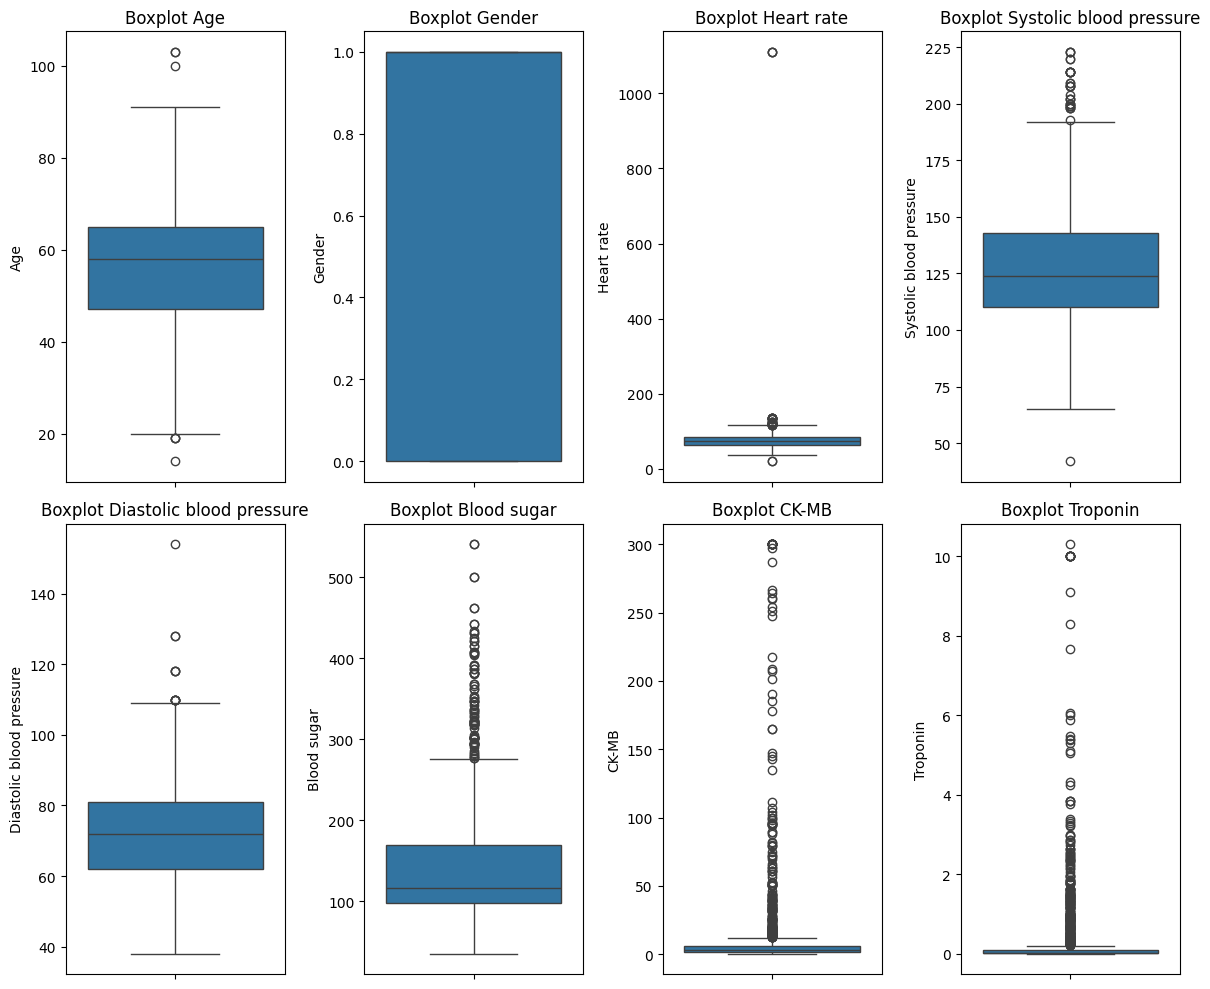

In [ ]:
data.columns = data.columns.str.strip()

plt.figure(figsize=(12, 10))
numeric_cols = ['Age', 'Gender', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
plt.tight_layout()
plt.savefig('boxplot_fitur_numerik.png')
plt.show()

### 1.4 Pre-processing Dataset
#### 1.4.1 Penanganan Outliers

In [ ]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    outliers_removed = 0

    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_count = len(df_clean[(df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)])
        outliers_removed += outliers_count
        print(f"Outliers di kolom {column}: {outliers_count} data")

        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]

    print(f"\nTotal outliers yang dihapus: {outliers_removed}")
    print(f"Data tersisa: {len(df_clean)} dari {len(df)} data asli")

    return df_clean

In [ ]:
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
if 'Gender' in numeric_columns:
    numeric_columns.remove('Gender')

data_clean = remove_outliers_iqr(data, numeric_columns)
data = data_clean.copy()

Outliers di kolom Age: 7 data
Outliers di kolom Heart rate: 30 data
Outliers di kolom Systolic blood pressure: 29 data
Outliers di kolom Diastolic blood pressure: 6 data
Outliers di kolom Blood sugar: 85 data
Outliers di kolom CK-MB: 179 data
Outliers di kolom Troponin: 195 data

Total outliers yang dihapus: 531
Data tersisa: 788 dari 1319 data asli


#### 1.4.2 Analisis Distribusi Target Variable

In [ ]:
print("\nDistribusi Target Variable (Result):")
result_distribution = data['Result'].value_counts()
print(result_distribution)
print(f"\nJumlah data Keseluruhan: {len(data)}")

for category in result_distribution.index:
    percentage = result_distribution[category]/len(data)*100
    print(f"Persentase pasien dengan result {category}: {percentage:.2f}%")


Distribusi Target Variable (Result):
Result
negative    446
positive    342
Name: count, dtype: int64

Jumlah data Keseluruhan: 788
Persentase pasien dengan result negative: 56.60%
Persentase pasien dengan result positive: 43.40%


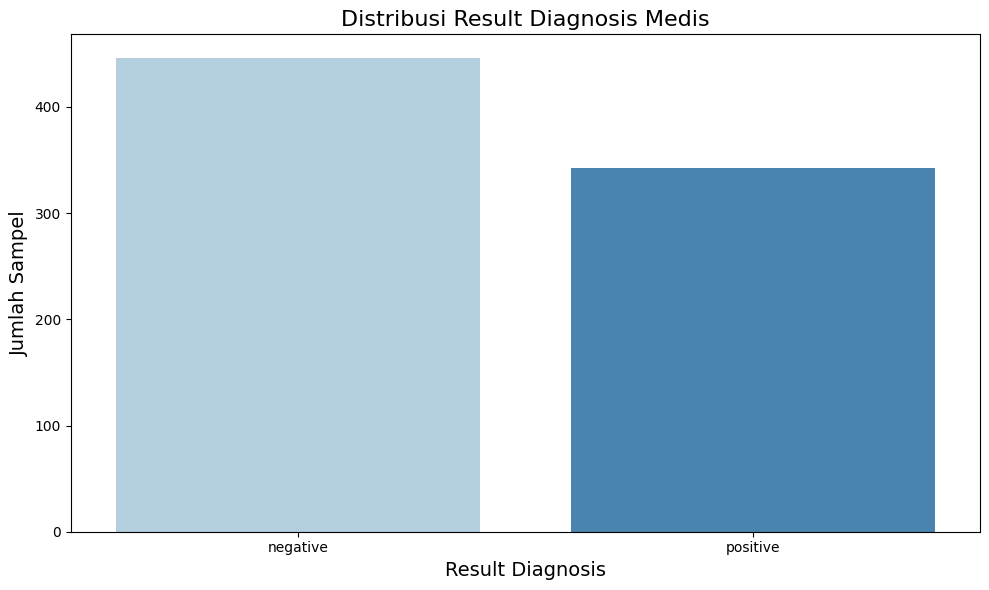

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Result', data=data, hue='Result', palette='Blues')
plt.title('Distribusi Result Diagnosis Medis', fontsize=16)
plt.xlabel('Result Diagnosis', fontsize=14)
plt.ylabel('Jumlah Sampel', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_result_diagnosis.png')
plt.show()

#### 1.4.3 Analisis Distribusi Fitur Numerik

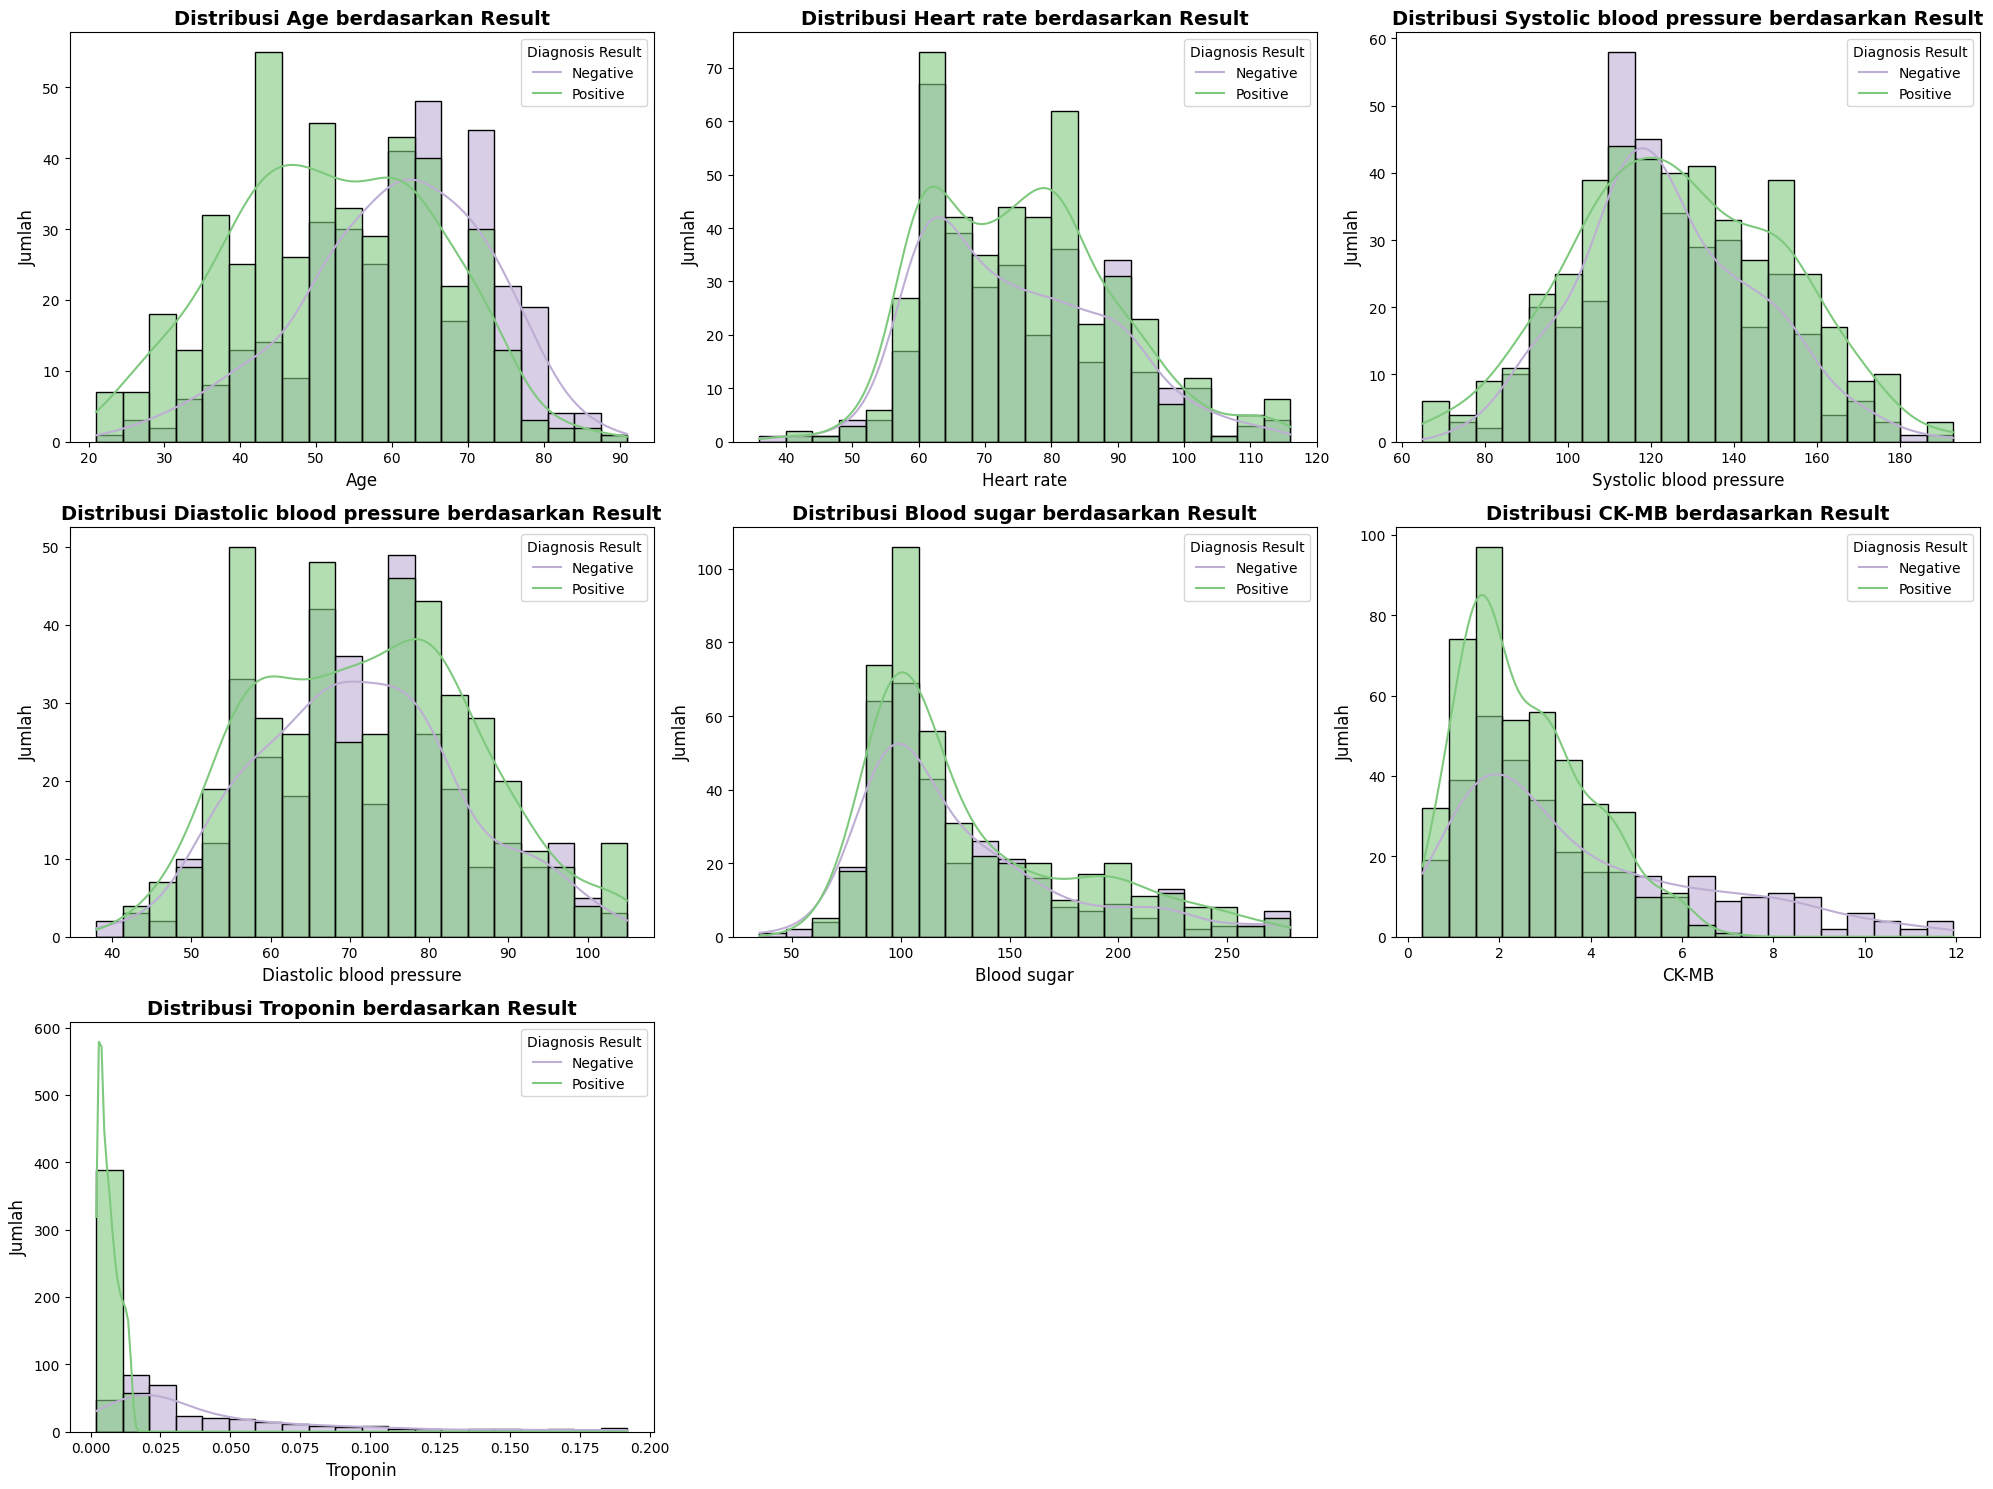

In [ ]:
plt.figure(figsize=(20, 15))
numerical_features = ['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']
for i, column in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=data, x=column, hue='Result', kde=True, palette='Accent',
                 bins=20, stat='count', alpha=0.6)
    plt.title(f'Distribusi {column} berdasarkan Result', fontsize=14, weight='bold')
    plt.xlabel(f'{column}', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)
    plt.legend(title='Diagnosis Result', labels=['Negative', 'Positive'], fontsize=10)
plt.tight_layout()
plt.savefig('distribusi_variabel_numerik.png', dpi=300)
plt.show()

#### 1.4.4 Analisis Fitur Kategorik

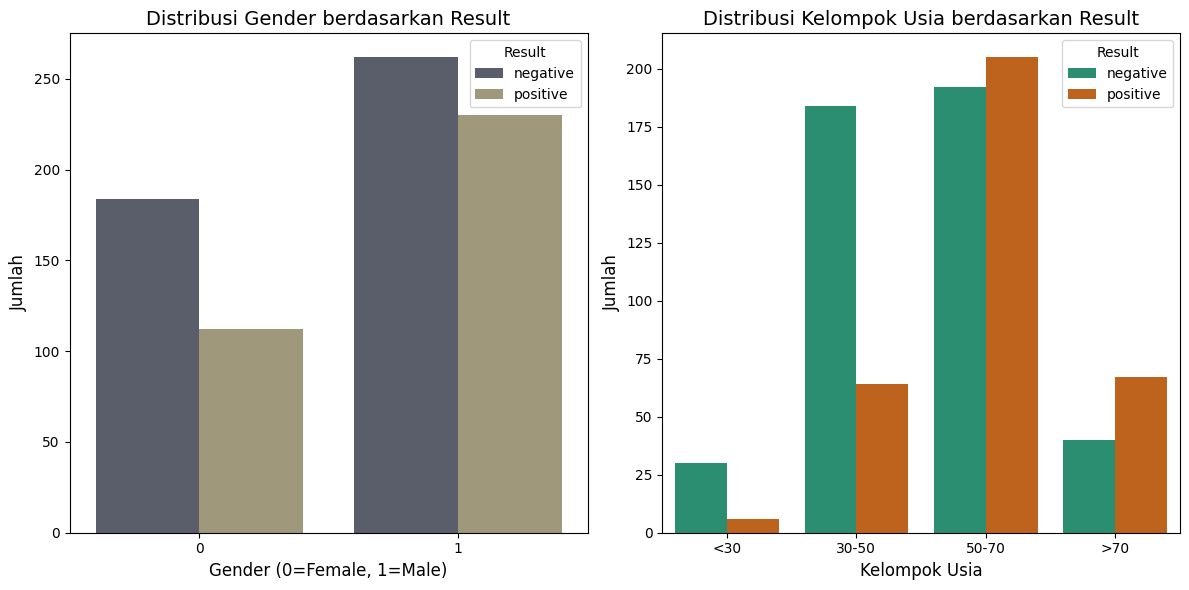

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Gender', hue='Result', data=data, palette='cividis')
plt.title('Distribusi Gender berdasarkan Result', fontsize=14)
plt.xlabel('Gender (0=Female, 1=Male)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

plt.subplot(1, 2, 2)
data['Age_Group'] = pd.cut(data['Age'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '>70'])
sns.countplot(x='Age_Group', hue='Result', data=data, palette='Dark2')
plt.title('Distribusi Kelompok Usia berdasarkan Result', fontsize=14)
plt.xlabel('Kelompok Usia', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

plt.tight_layout()
plt.savefig('distribusi_variabel_kategorik.png')
plt.show()

#### 1.4.5 Analisis Korelasi

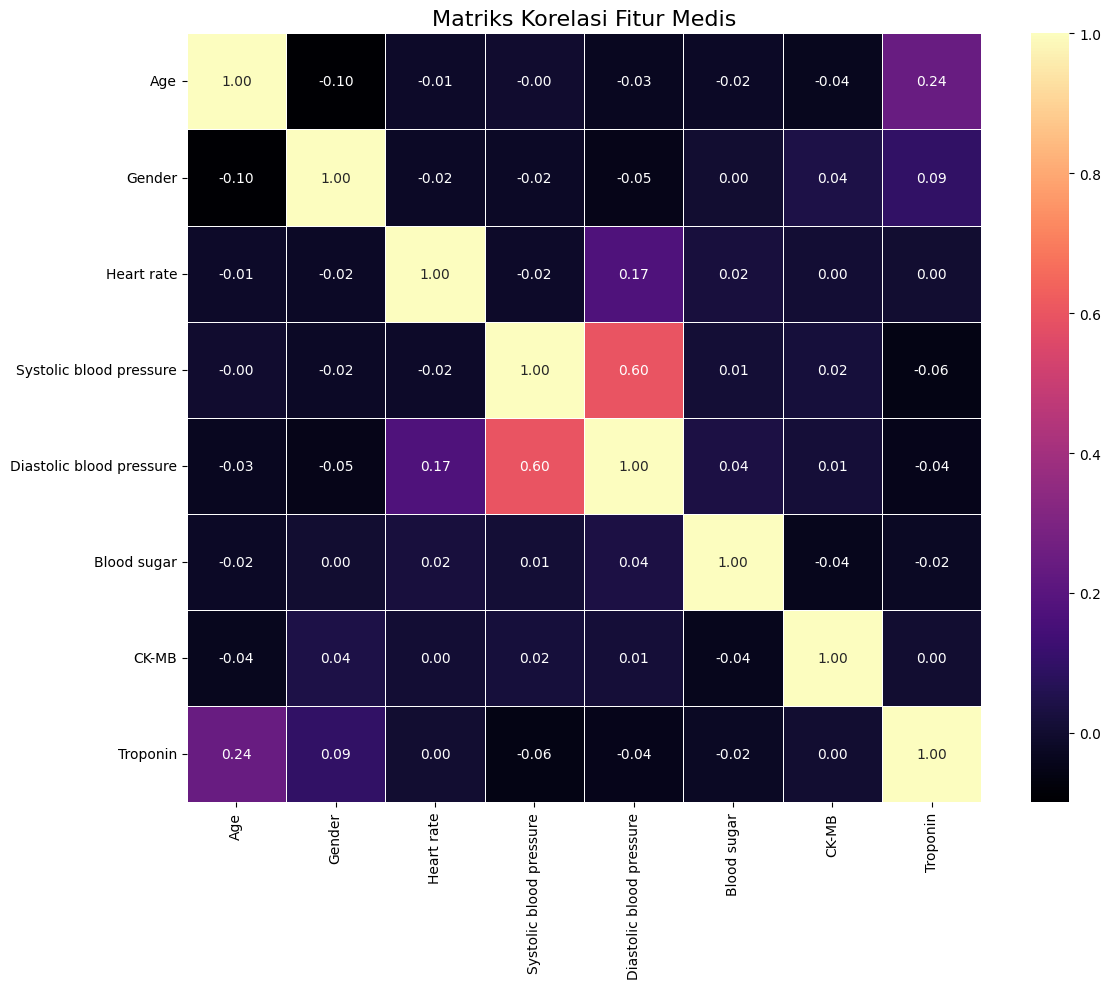

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='magma', linewidths=0.5, fmt='.2f')
plt.title('Matriks Korelasi Fitur Medis', fontsize=16)
plt.tight_layout()
plt.savefig('matriks_korelasi_medis.png')
plt.show()

## 2. PERSIAPAN DATA UNTUK MODELING

### 2.1 Encoding dan Feature Selection

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['Result'])
X = data.drop(['Result', 'Age_Group'], axis=1, errors='ignore')

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Kolom dlm data:", numerical_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Kolom dlm data: ['Age', 'Gender', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5), threshold="mean")
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print(f"Jumlah fitur sebelum seleksi: {X_train_scaled.shape[1]}")
print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]}")

print(f"\nBentuk set pelatihan: {X_train.shape}")
print(f"Bentuk set pengujian: {X_test.shape}")

Jumlah fitur sebelum seleksi: 8
Jumlah fitur setelah seleksi: 2

Bentuk set pelatihan: (630, 8)
Bentuk set pengujian: (158, 8)


In [ ]:
print("\nDistribusi kelas pada data training:")
unique, counts = np.unique(y_train, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nDistribusi kelas pada data testing:")
unique, counts = np.unique(y_test, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count/len(y_test)*100:.1f}%)")


Distribusi kelas pada data training:
negative: 357 (56.7%)
positive: 273 (43.3%)

Distribusi kelas pada data testing:
negative: 89 (56.3%)
positive: 69 (43.7%)


### 2.2 Penanganan Imbalanced Dataset dengan SMOTE
SMOTE (Synthetic Minority Oversampling Technique) digunakan untuk mengatasi ketidakseimbangan kelas dengan membuat sampel sintetis untuk kelas minoritas.

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("\nDistribusi sebelum SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")

print("\nDistribusi setelah SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")


Distribusi sebelum SMOTE:
negative: 357
positive: 273

Distribusi setelah SMOTE:
negative: 357
positive: 357


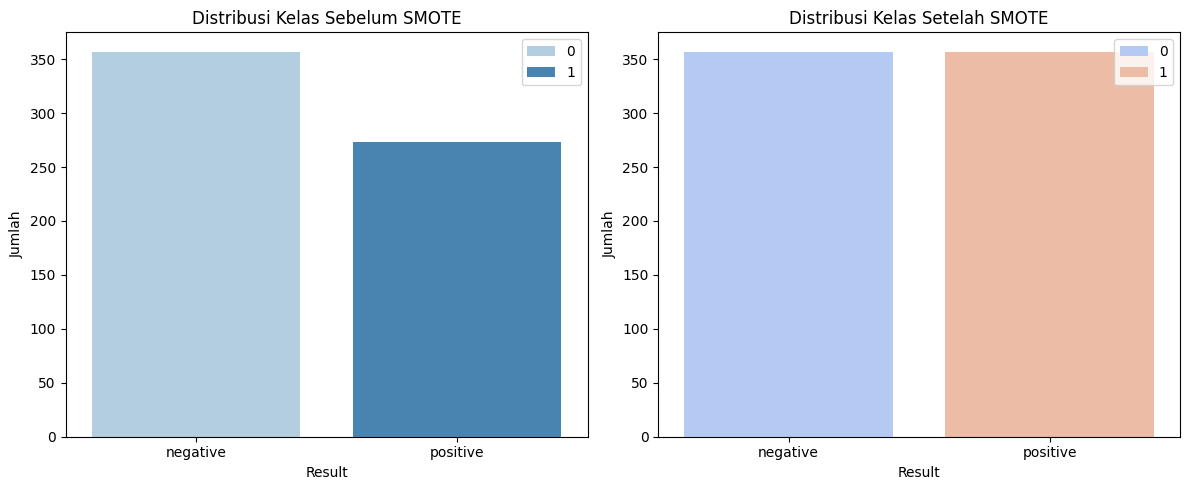

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette='Blues')
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Result")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, hue=y_train_smote, palette='coolwarm')
plt.title("Distribusi Kelas Setelah SMOTE")
plt.xlabel("Result")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.tight_layout()
plt.savefig("distribusi_setelah_smote_medis.png")
plt.show()

## 3. METODE DAN EKSPERIMEN

### 3.1 Fungsi Visualisasi Matriks konfusi

In [ ]:
def plot_matriks_konfusi(y_true, y_pred, title="Model"):
    labels = sorted(list(set(y_true)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

    plt.xlabel("Label Prediksi")
    plt.ylabel("Label Sebenarnya")
    plt.title(f"Matriks Konfusi - {title}")
    plt.tight_layout()
    plt.show()

### 3.2 Model 1: Decision Tree Classifier
Decision Tree adalah algoritma supervised learning yang menggunakan struktur pohon untuk membuat keputusan. Algoritma ini mudah diinterpretasi dan dapat menangani data numerik maupun kategorikal.

#### 3.2.1 Hyperparameter Tuning

In [ ]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_dt.fit(X_train_smote, y_train_smote)

dt_model_best = grid_dt.best_estimator_
dt_model_best.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [ ]:
dt_train_pred = dt_model_best.predict(X_train_smote)

dt_accuracy = accuracy_score(y_train_smote, dt_train_pred)
dt_precision = precision_score(y_train_smote, dt_train_pred, average='weighted')
dt_recall = recall_score(y_train_smote, dt_train_pred, average='weighted')
dt_f1 = f1_score(y_train_smote, dt_train_pred, average='weighted')

print("Metrik Evaluasi Decision Tree pada Data Training")
print(f"Akurasi: {dt_accuracy:.4f}")
print(f"Presisi: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")

Metrik Evaluasi Decision Tree pada Data Training
Akurasi: 0.9818
Presisi: 0.9824
Recall: 0.9818
F1-Score: 0.9818


In [ ]:
dt_test_pred = dt_model_best.predict(X_test_selected)

dt_test_accuracy = accuracy_score(y_test, dt_test_pred)
dt_test_precision = precision_score(y_test, dt_test_pred, average='weighted')
dt_test_recall = recall_score(y_test, dt_test_pred, average='weighted')
dt_test_f1 = f1_score(y_test, dt_test_pred, average='weighted')

print("Metrik Evaluasi Decision Tree pada Data Testing")
print(f"Akurasi: {dt_test_accuracy:.4f}")
print(f"Presisi: {dt_test_precision:.4f}")
print(f"Recall: {dt_test_recall:.4f}")
print(f"F1-Score: {dt_test_f1:.4f}")

print("\nLaporan Klasifikasi Decision Tree:")
print(classification_report(y_test, dt_test_pred, target_names=label_encoder.classes_))

Metrik Evaluasi Decision Tree pada Data Testing
Akurasi: 0.9873
Presisi: 0.9877
Recall: 0.9873
F1-Score: 0.9874

Laporan Klasifikasi Decision Tree:
              precision    recall  f1-score   support

    negative       1.00      0.98      0.99        89
    positive       0.97      1.00      0.99        69

    accuracy                           0.99       158
   macro avg       0.99      0.99      0.99       158
weighted avg       0.99      0.99      0.99       158



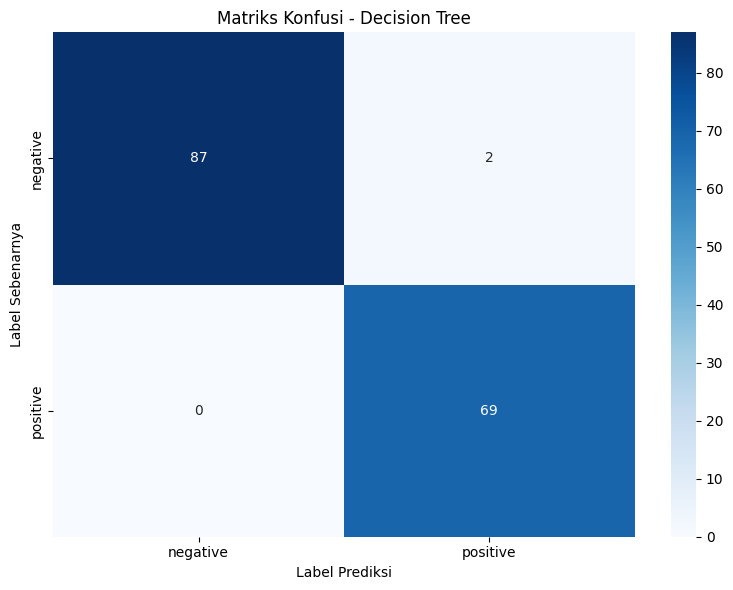

In [ ]:
plot_matriks_konfusi(y_test, dt_test_pred, "Decision Tree")

### 3.3 Model 2: Naive Bayes Classifier
Naive Bayes adalah algoritma probabilistik yang berdasarkan teorema Bayes dengan asumsi independensi antar fitur. Algoritma ini efektif untuk klasifikasi teks dan data dengan fitur yang relatif independen.

#### 3.3.1 Hyperparameter Tuning

In [ ]:
param_grid_nb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_nb.fit(X_train_smote, y_train_smote)
nb_model = grid_nb.best_estimator_
nb_model.fit(X_train_smote, y_train_smote)

GaussianNB(var_smoothing=1e-12)

In [ ]:
nb_train_pred = nb_model.predict(X_train_smote)
print("Metrik Evaluasi Naive Bayes pada Data Training")
print(f"Akurasi: {accuracy_score(y_train_smote, nb_train_pred):.4f}")
print(f"Presisi: {precision_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")

Metrik Evaluasi Naive Bayes pada Data Training
Akurasi: 0.9608
Presisi: 0.9622
Recall: 0.9608
F1-Score: 0.9608


In [ ]:
nb_test_pred = nb_model.predict(X_test_selected)
print("Metrik Evaluasi Naive Bayes pada Data Testing")
nb_accuracy = accuracy_score(y_test, nb_test_pred)
nb_precision = precision_score(y_test, nb_test_pred, average='weighted')
nb_recall = recall_score(y_test, nb_test_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_test_pred, average='weighted')

print(f"Akurasi: {nb_accuracy:.4f}")
print(f"Presisi: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")

print("\nLaporan Klasifikasi Naive Bayes:")
print(classification_report(y_test, nb_test_pred, target_names=label_encoder.classes_))

Metrik Evaluasi Naive Bayes pada Data Testing
Akurasi: 0.9684
Presisi: 0.9689
Recall: 0.9684
F1-Score: 0.9683

Laporan Klasifikasi Naive Bayes:
              precision    recall  f1-score   support

    negative       0.96      0.99      0.97        89
    positive       0.98      0.94      0.96        69

    accuracy                           0.97       158
   macro avg       0.97      0.97      0.97       158
weighted avg       0.97      0.97      0.97       158



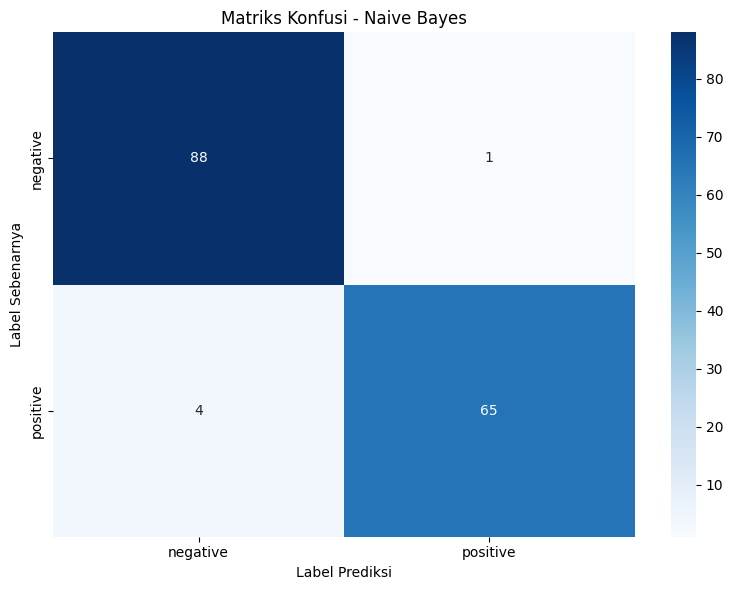

In [ ]:
plot_matriks_konfusi(y_test, nb_test_pred, "Naive Bayes")

## 4. HASIL DAN ANALISIS

### 4.1 Perbandingan Performa Model

In [ ]:
dt_metrics = [dt_test_accuracy, dt_test_precision, dt_test_recall, dt_test_f1]
nb_metrics = [nb_accuracy, nb_precision, nb_recall, nb_f1]

performance_df = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Naive Bayes': nb_metrics,
}, index=['Akurasi', 'Presisi', 'Recall', 'F1-Score'])

performance_df.head()

,Decision Tree,Naive Bayes
Akurasi,0.987342,0.968354
Presisi,0.987698,0.968892
Recall,0.987342,0.968354
F1-Score,0.987360,0.968265


<Figure size 1200x800 with 0 Axes>

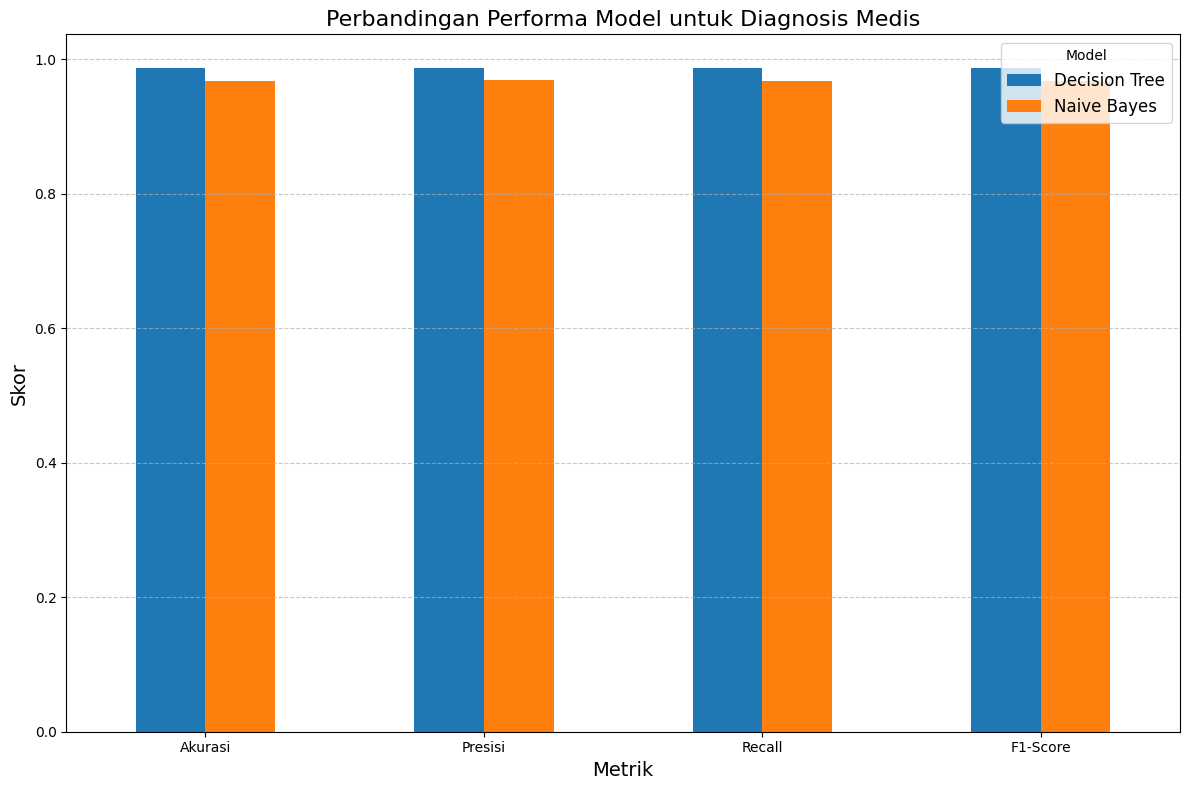

In [ ]:
plt.figure(figsize=(12, 8))
performance_df.plot(kind='bar', figsize=(12, 8), rot=0)
plt.title('Perbandingan Performa Model untuk Diagnosis Medis', fontsize=16)
plt.ylabel('Skor', fontsize=14)
plt.xlabel('Metrik', fontsize=14)
plt.legend(title='Model', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('perbandingan_performa_model_medis.png')
plt.show()

### 4.2 Analisis Feature Importance
Analisis ini menunjukkan fitur-fitur yang paling berpengaruh dalam prediksi diagnosis medis berdasarkan model Decision Tree.

In [ ]:
selected_features = X.columns[selector.get_support()]
feature_importance_dt = dt_model_best.feature_importances_
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importance_dt
}).sort_values('Importance', ascending=False)

importance_df.head()

,Feature,Importance
1,Troponin,0.751288
0,CK-MB,0.248712


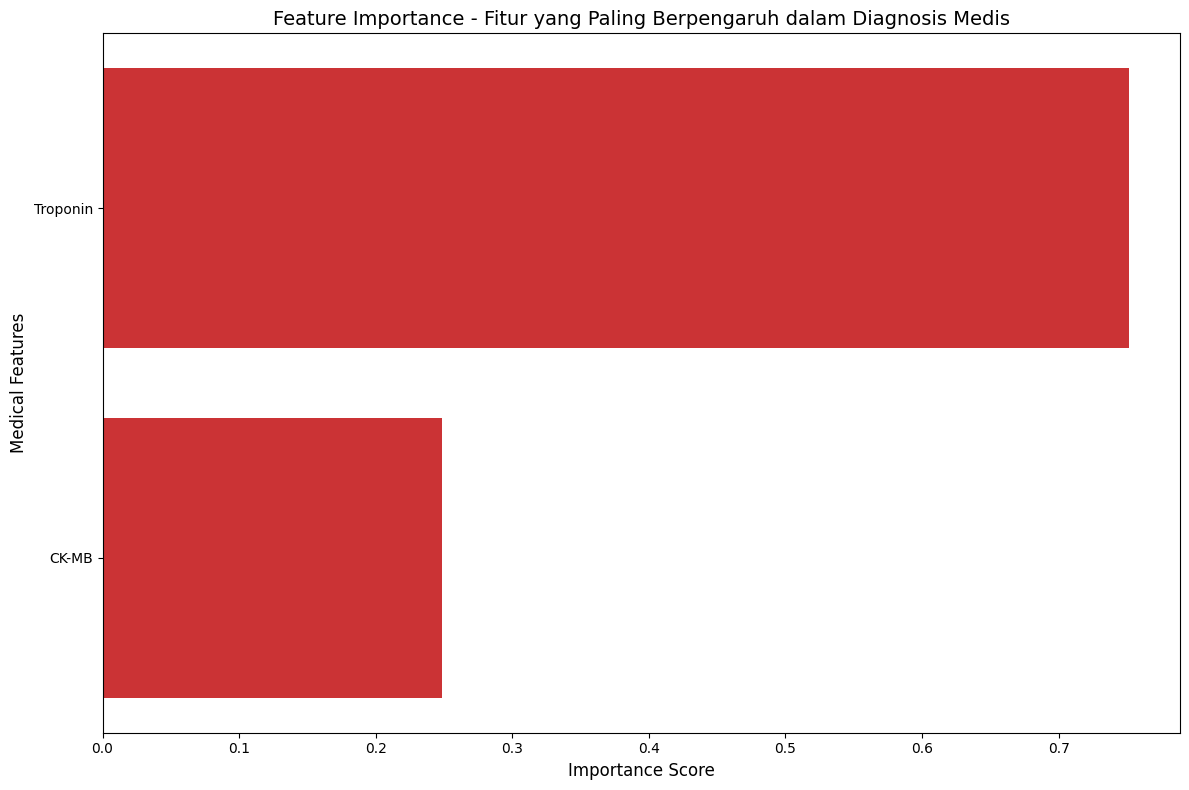

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', color=sns.color_palette('Set1')[0])
plt.title('Feature Importance - Fitur yang Paling Berpengaruh dalam Diagnosis Medis', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Medical Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_analysis.png')
plt.show()

### 4.3 Analisis Kinerja Detail

In [ ]:
best_accuracy_model = performance_df['Decision Tree'].idxmax()
best_accuracy_value = performance_df.loc['Akurasi', 'Decision Tree']
print(f"1. Model dengan akurasi tertinggi: Decision Tree (Akurasi: {best_accuracy_value:.4f})")
best_precision_model = performance_df['Decision Tree'].idxmax()
best_precision_value = performance_df.loc['Presisi', 'Decision Tree']
print(f"2. Model dengan presisi tertinggi: Decision Tree (Presisi: {best_precision_value:.4f})")
best_recall_model = performance_df['Decision Tree'].idxmax()
best_recall_value = performance_df.loc['Recall', 'Decision Tree']
print(f"3. Model dengan recall tertinggi: Decision Tree (Recall: {best_recall_value:.4f})")
best_f1_model = performance_df['Decision Tree'].idxmax()
best_f1_value = performance_df.loc['F1-Score', 'Decision Tree']
print(f"4. Model dengan F1-Score tertinggi: Decision Tree (F1-Score: {best_f1_value:.4f})")
print(f"5. Fitur paling penting: {importance_df.iloc[0]['Feature']} (Score: {importance_df.iloc[0]['Importance']:.4f})")
print(f"6. Fitur kedua terpenting: {importance_df.iloc[1]['Feature']} (Score: {importance_df.iloc[1]['Importance']:.4f})")

print("\nRINGKASAN PERFORMA TERBAIK:")
best_accuracy = performance_df.loc['Akurasi', 'Decision Tree']
best_f1 = performance_df.loc['F1-Score', 'Decision Tree']
best_model_overall = 'Decision Tree'
print(f"Model terbaik secara keseluruhan: {best_model_overall}")
print(f"Akurasi terbaik: {best_accuracy:.4f}")
print(f"F1-Score terbaik: {best_f1:.4f}")

1. Model dengan akurasi tertinggi: Decision Tree (Akurasi: 0.9873)
2. Model dengan presisi tertinggi: Decision Tree (Presisi: 0.9877)
3. Model dengan recall tertinggi: Decision Tree (Recall: 0.9873)
4. Model dengan F1-Score tertinggi: Decision Tree (F1-Score: 0.9874)
5. Fitur paling penting: Troponin (Score: 0.7513)
6. Fitur kedua terpenting: CK-MB (Score: 0.2487)

RINGKASAN PERFORMA TERBAIK:
Model terbaik secara keseluruhan: Decision Tree
Akurasi terbaik: 0.9873
F1-Score terbaik: 0.9874


# KESIMPULAN

Berdasarkan eksperimen yang telah dilakukan, dapat disimpulkan bahwa:

### 5.1 Preprocessing Data
- **Penghapusan outliers** menggunakan metode IQR berhasil membersihkan data dari nilai-nilai ekstrem yang dapat mempengaruhi performa model. Data yang tersisa setelah preprocessing memberikan kualitas yang lebih baik untuk training model, yang meningkatkan keakuratan dan stabilitas model.

### 5.2 Penanganan Imbalanced Data
- **Penggunaan SMOTE** berhasil menyeimbangkan distribusi kelas dari data yang tidak seimbang. Hal ini memberikan manfaat signifikan dalam meningkatkan performa model, terutama untuk kelas minoritas, yang tercermin dari peningkatan nilai **precision** dan **recall** pada model.

### 5.3 Feature Selection
- **Seleksi fitur** menggunakan model **Random Forest** berhasil mengurangi dimensi data menjadi fitur-fitur yang paling relevan untuk prediksi. Fitur yang dipilih memiliki kontribusi signifikan dalam akurasi prediksi, seperti yang terlihat dari **Troponin** dan **CK-MB** yang menunjukkan **importance** yang sangat tinggi.

### 5.4 Perbandingan Model
Berdasarkan evaluasi yang dilakukan:
- **Decision Tree** memberikan hasil yang sangat baik dengan **Akurasi 0.9873**, **Precision 0.9877**, **Recall 0.9873**, dan **F1-Score 0.9874**, menjadikannya model yang sangat kompetitif dan sangat bisa diinterpretasi.
- **Naive Bayes** meskipun efisien secara komputasi, menunjukkan akurasi yang sedikit lebih rendah dibandingkan Decision Tree. Akan tetapi, performa Naive Bayes masih cukup kompetitif di kasus ini.

### 5.5 Feature Importance
Fitur-fitur medis yang paling berpengaruh dalam diagnosis adalah:
1. **Troponin**: Biomarker utama untuk kerusakan otot jantung, dengan **Importance 0.7513**.
2. **CK-MB**: Enzim yang menunjukkan kerusakan otot jantung, dengan **Importance 0.2487**.
3. **Parameter tekanan darah**: Indikator penting untuk kesehatan kardiovaskular, meskipun tidak termasuk di antara tiga teratas dalam fitur penting.

### 5.6 Rekomendasi
- **Decision Tree** direkomendasikan untuk implementasi sistem diagnosis medis karena:
  - Memberikan akurasi yang tinggi dan stabilitas performa yang luar biasa berdasarkan hasil **cross-validation**.
  - Mudah diinterpretasi oleh tenaga medis, memberikan jalur keputusan yang jelas untuk diagnosis.
  - Performa yang lebih baik secara keseluruhan dibandingkan Naive Bayes.






